In [1]:
import pandas as pd
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
import tensorflow as tf
import keras.backend as K
from tensorflow import keras
from tensorflow.keras import Sequential, layers, callbacks
from keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.layers import Dropout
from keras_tuner.tuners import RandomSearch
from keras_tuner.engine.hyperparameters import HyperParameters
#sns.set(font_scale=1.5, style="whitegrid")
plt.style.use('seaborn')

2025-03-22 15:43:56.035371: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-22 15:43:57.272258: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-22 15:43:57.538125: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-22 15:43:59.373664: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-22 15:44:11.983898: W tensorflow/compiler/tf2

In [2]:
# Set random seed for reproducibility
np.random.seed(1705)
tf.random.set_seed(1705)

## Chargement de la base de données  

In [3]:
## chargement de l'echantillon
file = 'data.csv'
data= pd.read_csv(file, parse_dates = ['time'], index_col = 'time')
data

,longitude,latitude,Temp_2m,SST,Total_precip,level,Rel_hum,Spec_hum,U_wind,V_wind
time,,,,,,,,,,
2020-06-01 00:00:00,-20.00,17.00,294.49365,296.05640,0.000000,100,51.933450,0.000003,13.262855,12.979732
2020-06-01 00:00:00,-6.75,7.00,298.11673,0.00000,0.000000,700,63.556664,0.006822,0.164469,0.276195
2020-06-01 00:00:00,-3.25,15.25,305.32526,0.00000,0.000000,600,88.835190,0.006115,-3.804608,3.357335
2020-06-01 00:00:00,7.25,6.50,299.05032,0.00000,0.000000,200,81.059395,0.000067,6.105811,11.218180
2020-06-01 00:00:00,-11.00,13.75,303.65753,0.00000,0.000000,200,14.945511,0.000013,13.687340,12.317312
...,...,...,...,...,...,...,...,...,...,...
2020-08-31 23:00:00,-13.50,6.75,299.20703,299.96014,0.000028,200,100.703926,0.000075,-13.307868,3.879082
2020-08-31 23:00:00,3.50,15.75,300.99442,0.00000,0.000000,700,95.161354,0.009621,3.527139,0.357029
2020-08-31 23:00:00,-13.50,7.00,299.20703,299.94467,0.000041,100,79.105644,0.000004,-19.953796,5.337244


In [4]:
## Sampling the data
# shuffle the DataFrame rows un random sampling de 1% de la base de données initiale. 
dataset = data.sample(frac =0.1)
# ordonner le dataset
dataset = dataset.sort_index()
## ramener time au colonne
#dataset=dataset.reset_index()
# ramener time au format datetime
#dataset['time'] = pd.to_datetime(dataset['time'])
dataset

,longitude,latitude,Temp_2m,SST,Total_precip,level,Rel_hum,Spec_hum,U_wind,V_wind
time,,,,,,,,,,
2020-06-01 00:00:00,-9.25,10.25,295.70642,0.0000,0.000019,825,19.106361,0.003493,-4.359037,-1.631278
2020-06-01 00:00:00,-7.50,9.00,297.59885,0.0000,0.000000,825,55.462204,0.009162,-7.448824,2.492306
2020-06-01 00:00:00,10.00,17.00,301.31348,0.0000,0.000000,100,53.751373,0.000002,8.778333,9.025164
2020-06-01 00:00:00,2.50,9.50,298.08698,0.0000,0.000000,100,67.503330,0.000003,8.431814,7.128189
2020-06-01 00:00:00,8.25,12.50,303.67720,0.0000,0.000000,1000,84.629940,0.017306,-0.693164,3.880132
...,...,...,...,...,...,...,...,...,...,...
2020-08-31 23:00:00,-16.50,14.75,300.23834,0.0000,0.000084,1000,86.910180,0.017188,-1.038238,1.499203
2020-08-31 23:00:00,6.25,13.00,298.44534,0.0000,0.000054,200,90.906470,0.000068,-11.729768,-3.321443
2020-08-31 23:00:00,-19.75,11.50,299.38510,301.3117,0.000290,1000,75.953010,0.016869,-2.047473,1.238854


In [5]:
# Select the target variable and features
target_variable = 'Total_precip'
features = ['longitude', 'latitude', 'Temp_2m','SST','level', 
            'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']

In [6]:
# Normalize the data
scaler = MinMaxScaler()
scaler_target = MinMaxScaler()
scaler_data= np.concatenate([scaler.fit_transform(dataset[['longitude', 'latitude', 'Temp_2m', 'SST','level',
                                                        'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']]),
                                scaler_target.fit_transform(dataset[[target_variable]])], axis = 1)

dataset= pd.DataFrame(scaler_data, columns =['longitude', 'latitude', 'Temp_2m', 'SST','level', 'Rel_hum', 
                                          'Spec_hum', 'U_wind', 'V_wind','Total_precip'] ,index=dataset.index)



In [7]:
# Create lag features
for feature in features:
    dataset[feature + '_lag1'] = dataset[feature].shift(1)
dataset.dropna(inplace=True)

In [8]:
# Update features list
lag_features = [f + '_lag1' for f in features]
all_features = features + lag_features

# Using Scikit-learn’s TimeSeriesSplit for Cross-Validation 

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

def plot_time_series_split(n_splits=5):
        """Visualize time series cross-validation splits"""
        tscv = TimeSeriesSplit(n_splits=n_splits)
        fig, axs = plt.subplots(n_splits, 1, figsize=(15, 5 * n_splits))
        for idx, (train_idx, test_idx) in enumerate(tscv.split(dataset)):
            train_data = dataset.iloc[train_idx]
            test_data = dataset.iloc[test_idx]
            axs[idx].plot(train_data.index, train_data[target_variable], label='Training')
            axs[idx].plot(test_data.index, test_data[target_variable], label='Validation')
            axs[idx].set_title(f'Split {idx + 1}')
            axs[idx].legend()
            plt.savefig(f"Split/{idx + 1}.jpg") # Enregistrement dans le dossier "images"
        plt.tight_layout()
        return fig

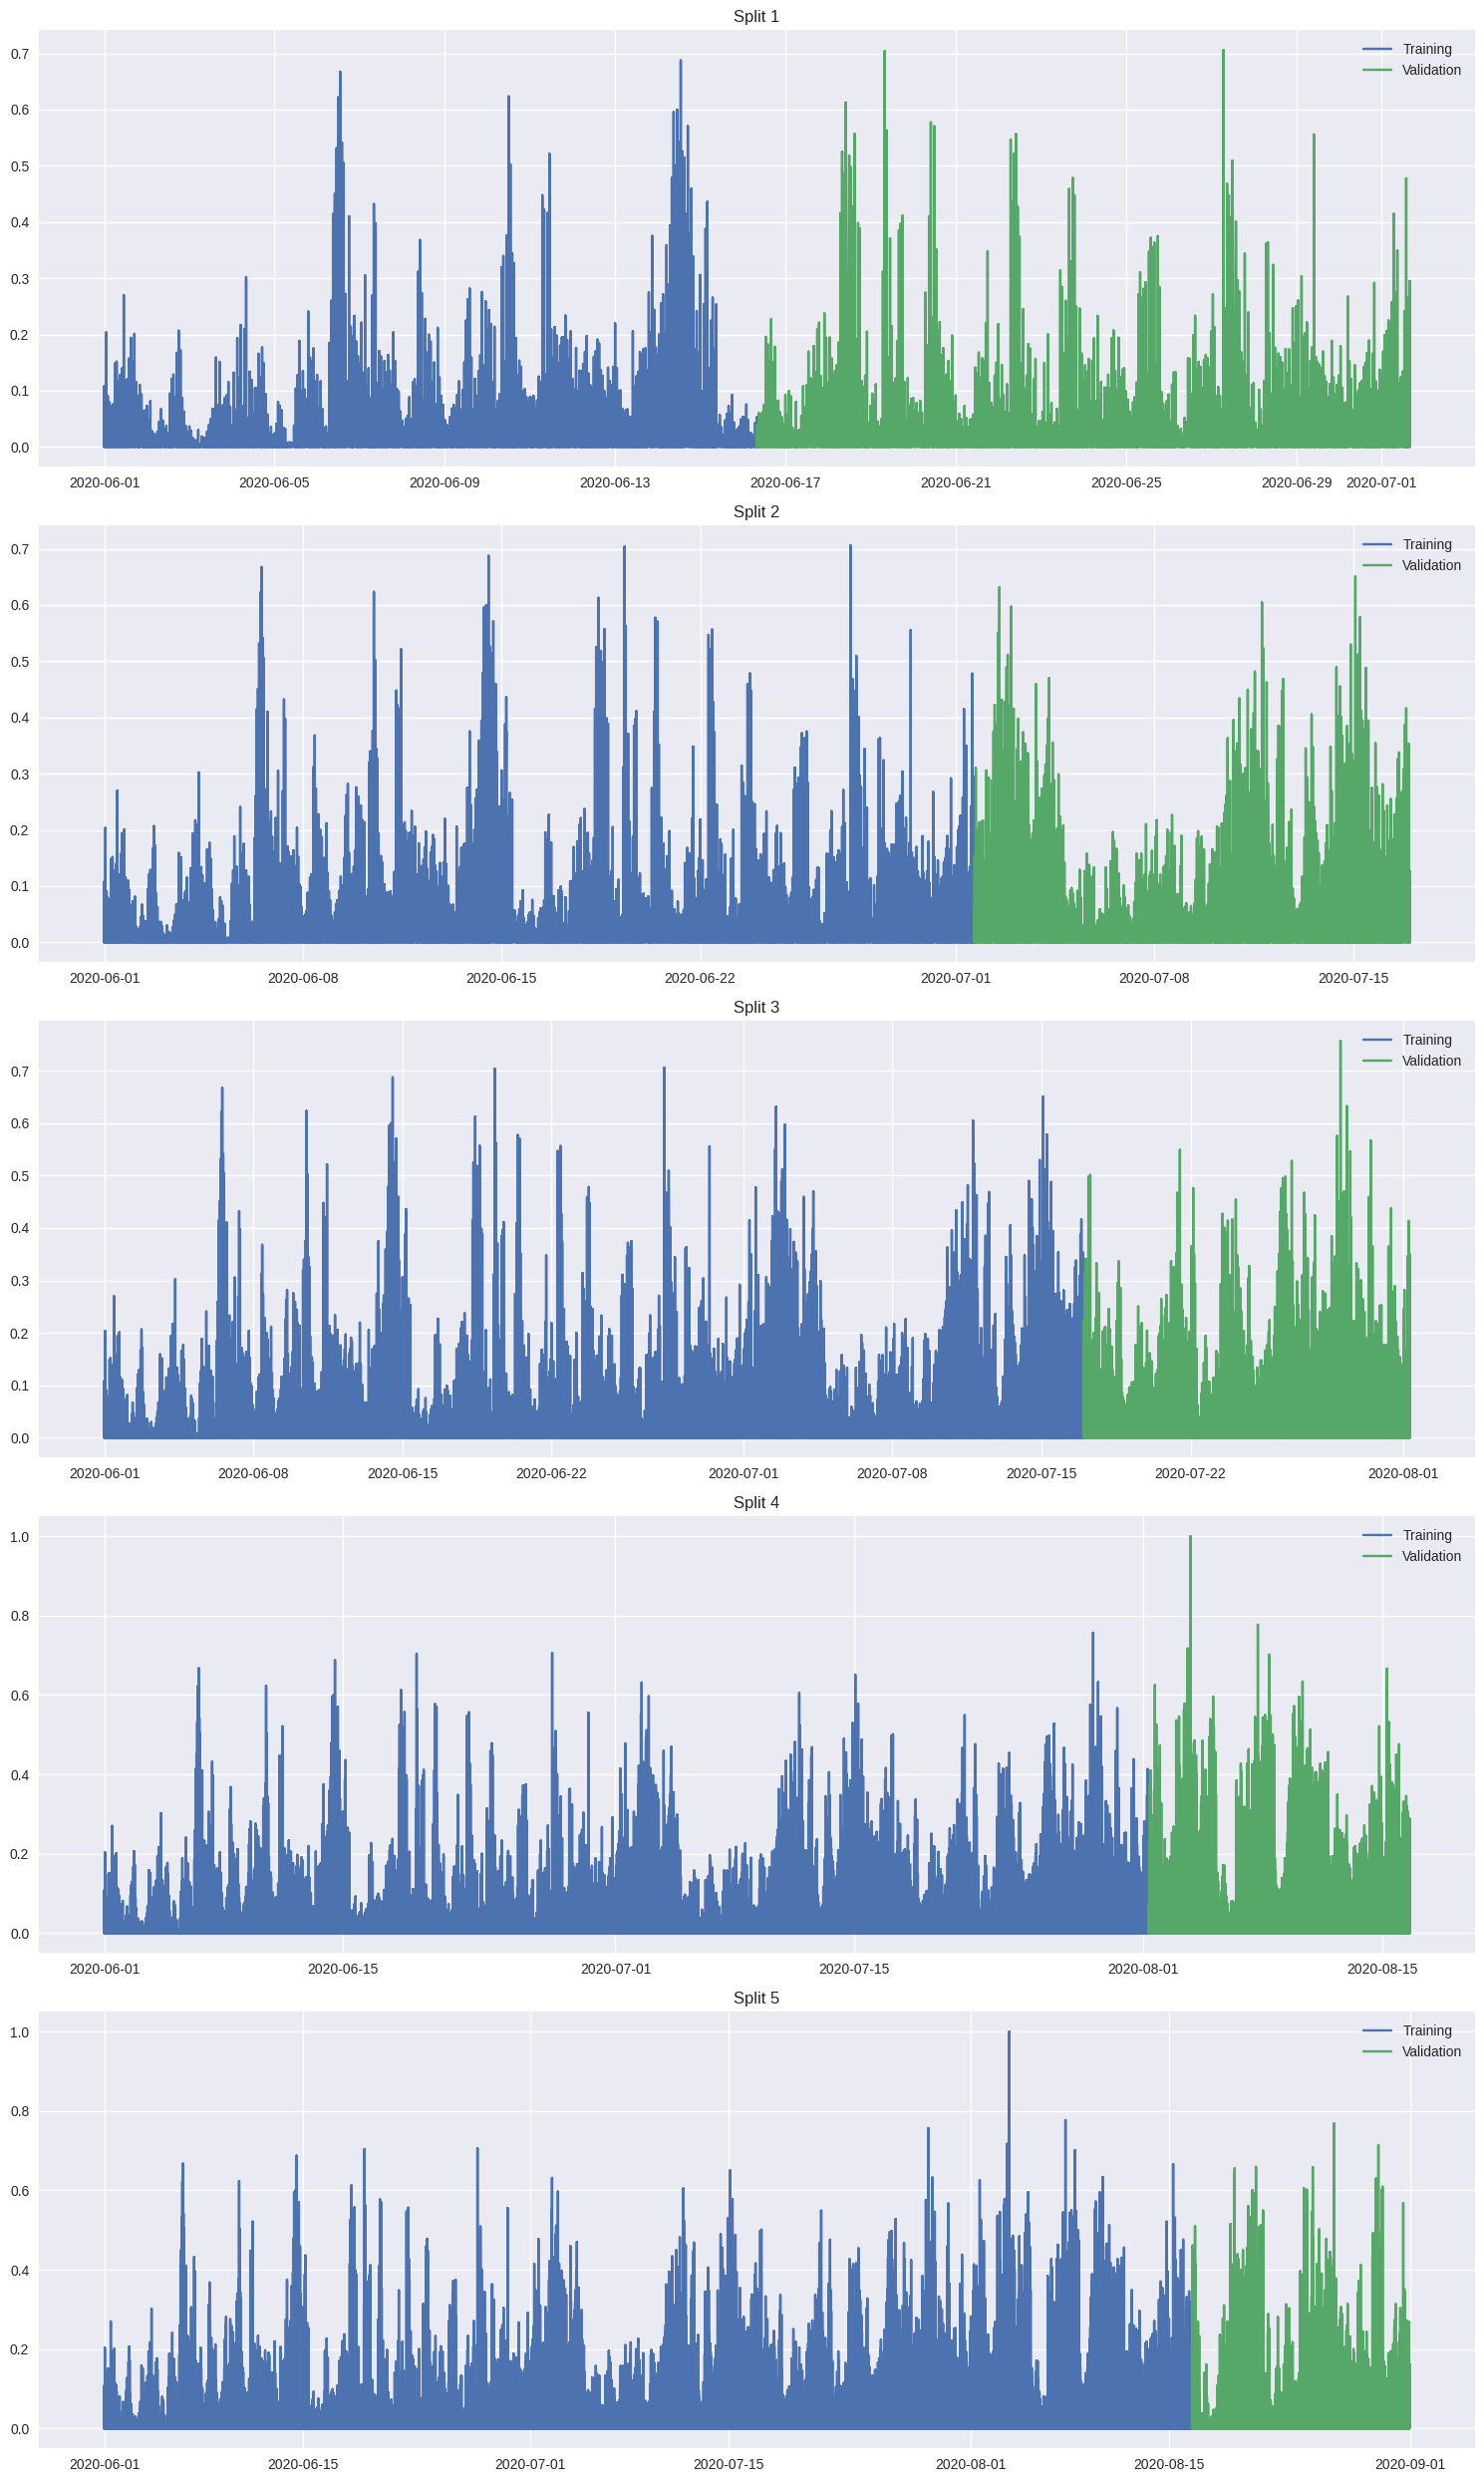

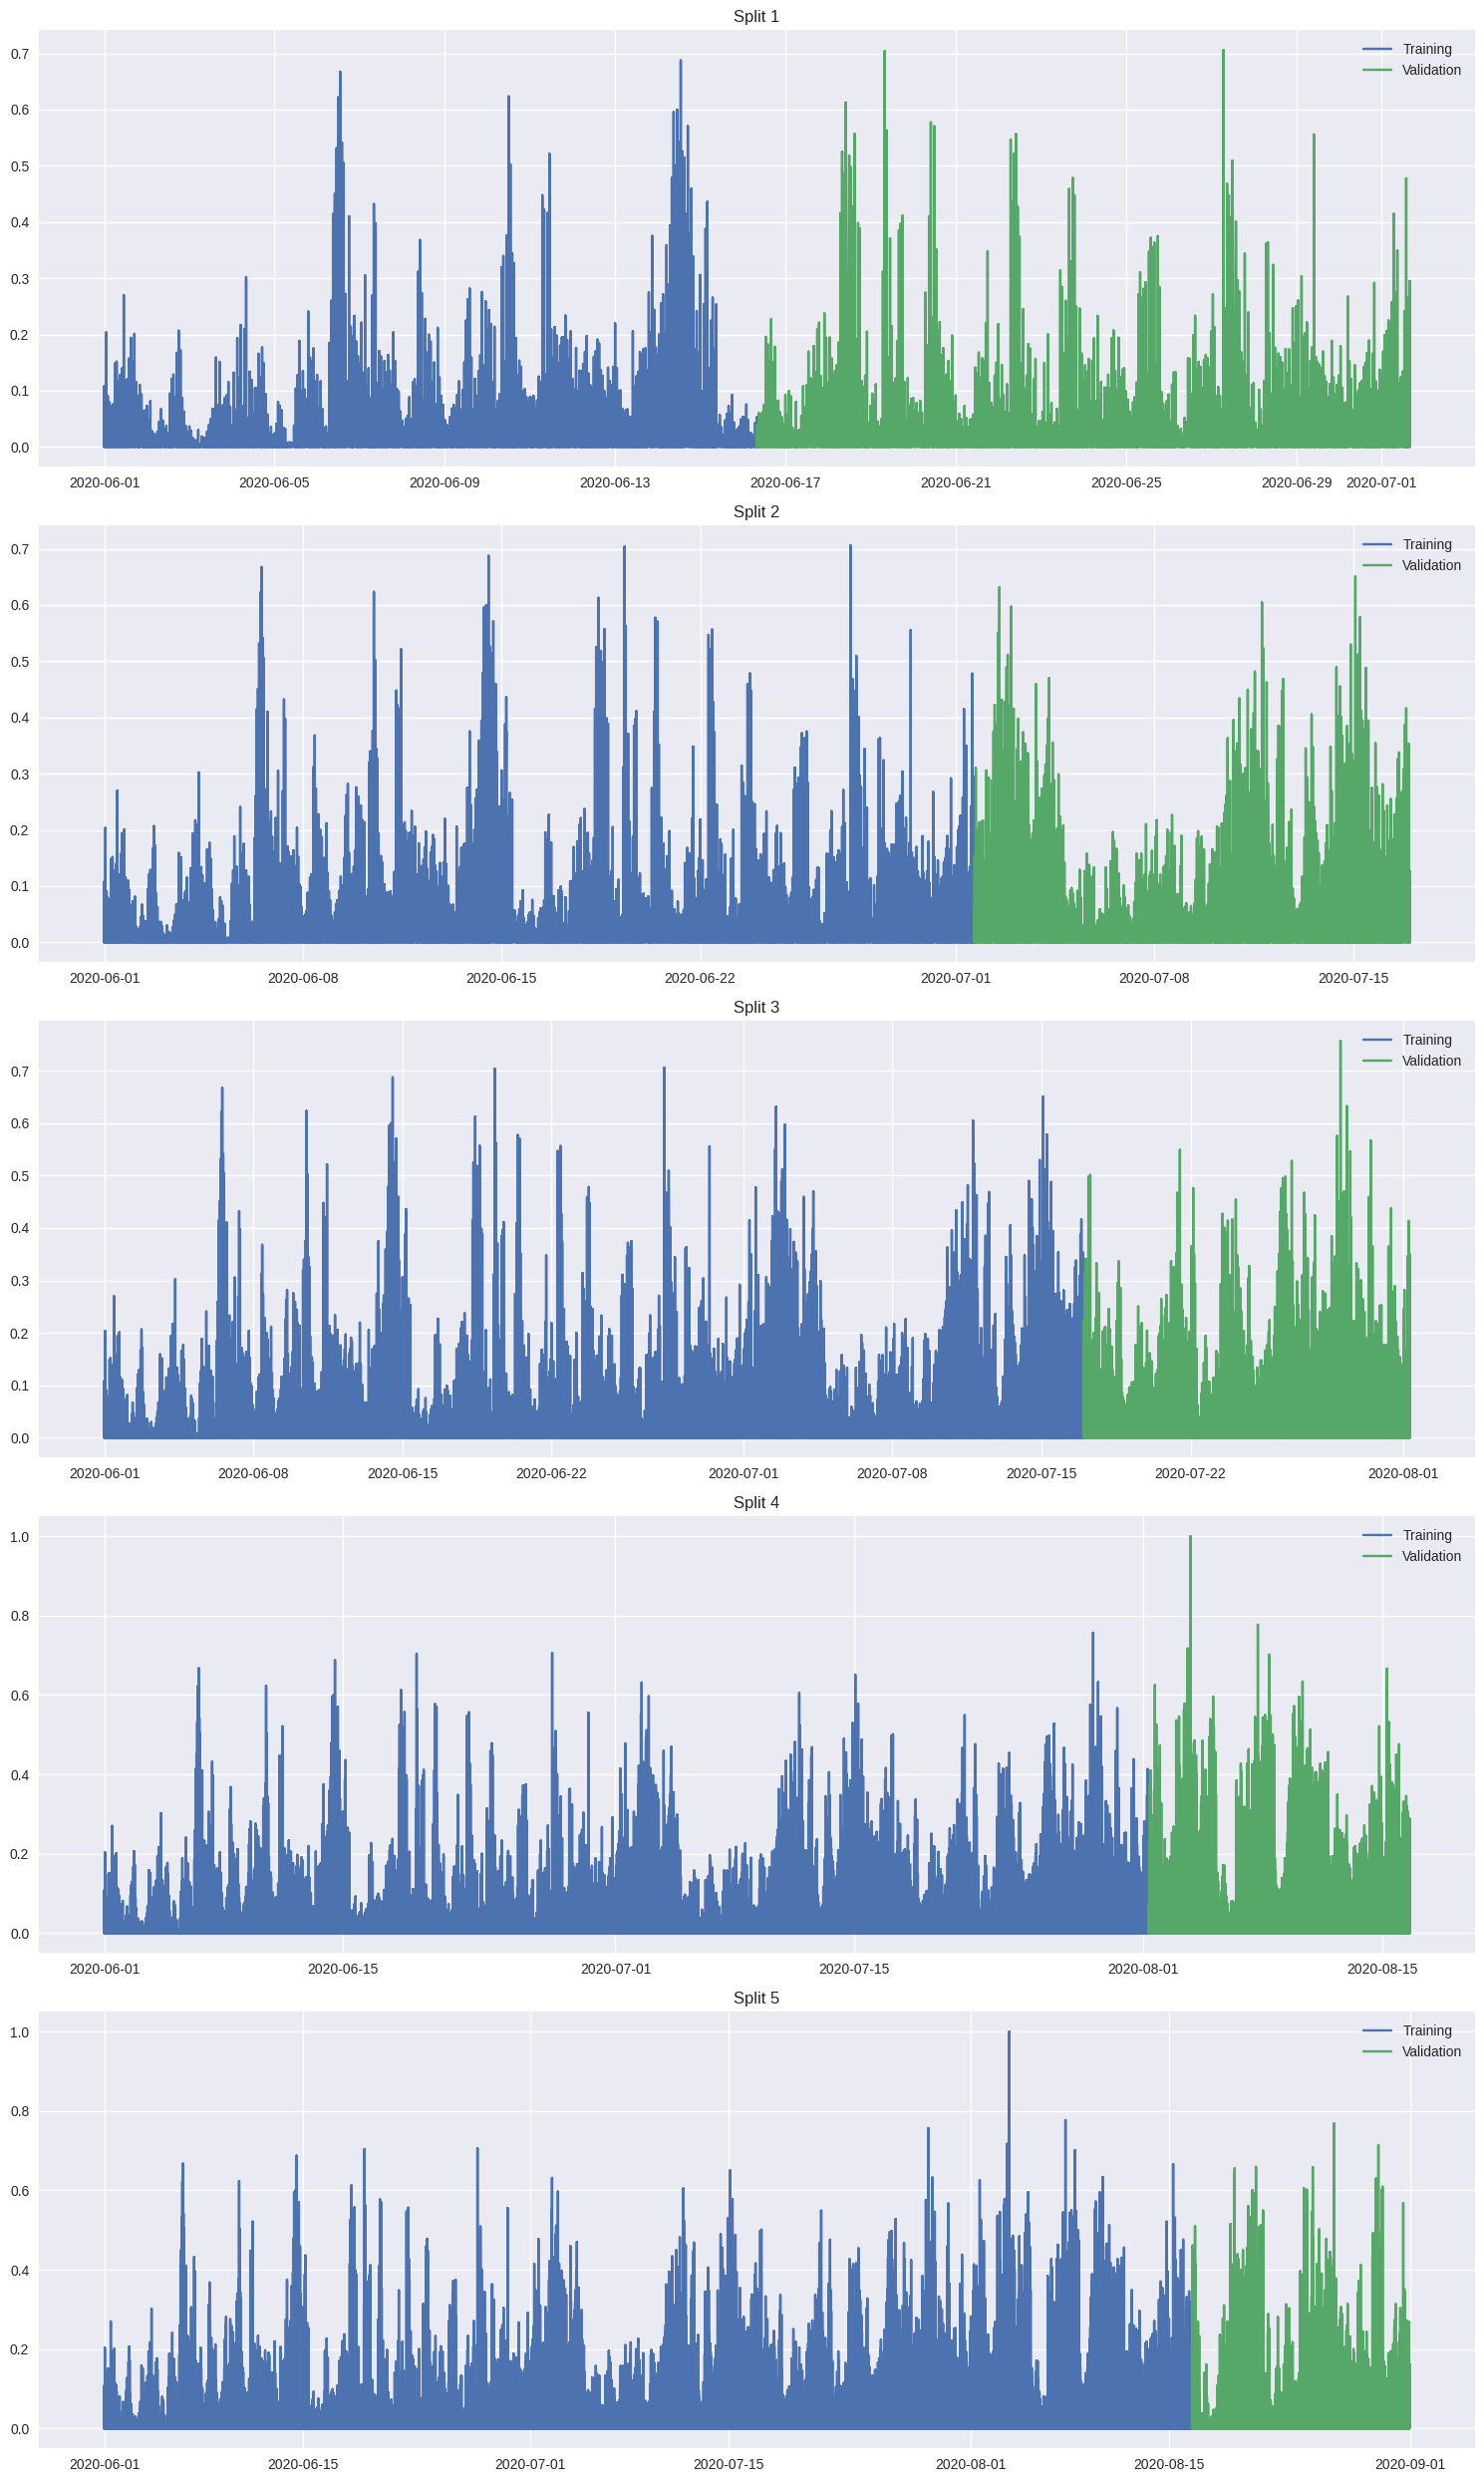

In [10]:
plot_time_series_split(n_splits=5)

In [35]:
import imageio as iio
frames = np.stack([iio.imread(f"Split/{i + 1}.jpg") for i in range(5)], axis = 0)

In [37]:
iio.mimwrite('TimeSeriesSplit.gif', frames)

In [11]:
tscv = TimeSeriesSplit(n_splits=5)
for idx, (train_idx, test_idx) in enumerate(tscv.split(dataset)):
            train_data = dataset.iloc[train_idx]
            test_data = dataset.iloc[test_idx]
# Prepare data for LSTM
X_train = train_data[all_features].values
y_train = train_data[target_variable].values
X_test = test_data[all_features].values
y_test = test_data[target_variable].values

In [12]:
# Reshape data for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

##  LSTM testing

In [13]:
# Create LSTM or GRU model
def create_model(units, m):
    model = Sequential()
    # First layer of LSTM
    model.add(m (units = units,activation="tanh", return_sequences = True, 
                 input_shape = [X_train.shape[1], X_train.shape[2]]))
    model.add(Dropout(0.4)) 
    # Second layer of LSTM
    model.add(m (units = units,return_sequences=False))                 
    model.add(Dropout(0.4))
    model.add(Dense(units = 1)) 
    #Compile model
    model.compile(loss='mse', optimizer='adam')
    return model

model_lstm = create_model(54, LSTM)

/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
# Fit BiLSTM, LSTM and GRU
def fit_model(model):
    early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                               patience = 10)

    # shuffle = False because the order of the data matters
    history = model.fit(X_train, y_train, epochs = 88, validation_split = 0.2,
                    batch_size = 16, shuffle = False, callbacks = [early_stop])
    return history


history_lstm = fit_model(model_lstm)


Epoch 1/88
54547/54547 ━━━━━━━━━━━━━━━━━━━━ 172s 3ms/step - loss: 2.1866e-04 - val_loss: 5.7117e-04
Epoch 2/88
54547/54547 ━━━━━━━━━━━━━━━━━━━━ 199s 3ms/step - loss: 2.1031e-04 - val_loss: 5.7015e-04
Epoch 3/88
54547/54547 ━━━━━━━━━━━━━━━━━━━━ 158s 3ms/step - loss: 2.0907e-04 - val_loss: 5.6679e-04
Epoch 4/88
54547/54547 ━━━━━━━━━━━━━━━━━━━━ 158s 3ms/step - loss: 2.1021e-04 - val_loss: 5.6706e-04
Epoch 5/88
54547/54547 ━━━━━━━━━━━━━━━━━━━━ 166s 3ms/step - loss: 2.0887e-04 - val_loss: 5.6712e-04
Epoch 6/88
54547/54547 ━━━━━━━━━━━━━━━━━━━━ 169s 3ms/step - loss: 2.0914e-04 - val_loss: 5.6710e-04
Epoch 7/88
54547/54547 ━━━━━━━━━━━━━━━━━━━━ 160s 3ms/step - loss: 2.0897e-04 - val_loss: 5.6853e-04
Epoch 8/88
54547/54547 ━━━━━━━━━━━━━━━━━━━━ 158s 3ms/step - loss: 2.0873e-04 - val_loss: 5.6299e-04
Epoch 9/88
54547/54547 ━━━━━━━━━━━━━━━━━━━━ 158s 3ms/step - loss: 2.0824e-04 - val_loss: 5.6567e-04
Epoch 10/88
54547/54547 ━━━━━━━━━━━━━━━━━━━━ 158s 3ms/step - loss: 2.0995e-04 - val_loss: 5.6593e-04

/tmp/ipykernel_4718/2277420273.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


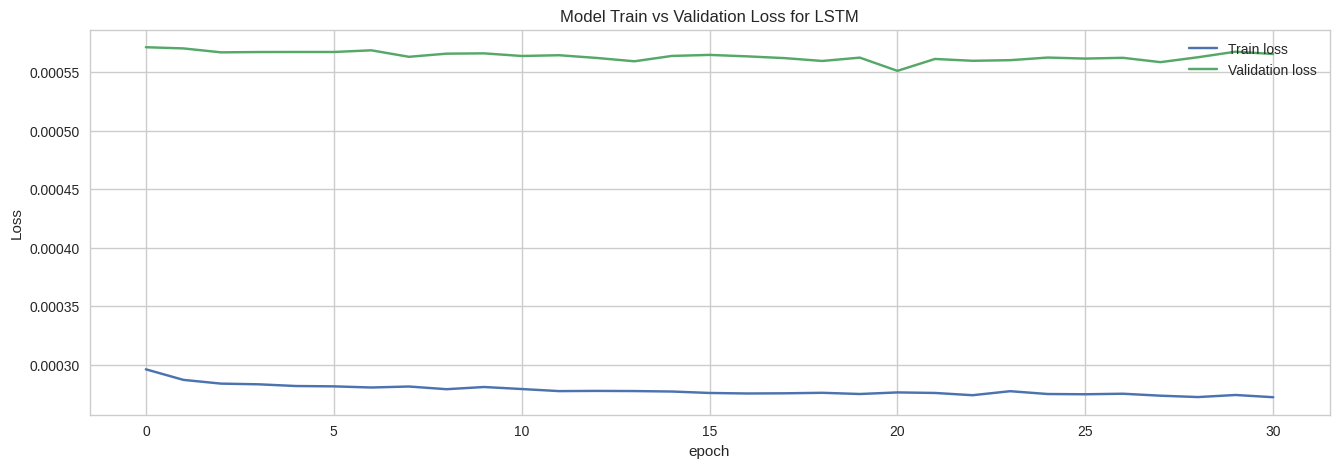

In [15]:
plt.style.use('seaborn-whitegrid')
def plot_loss (history, model_name):
    plt.figure(figsize = (16, 5))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Train vs Validation Loss for ' + model_name)
    plt.ylabel('Loss')
    plt.xlabel('epoch')
    plt.legend(['Train loss', 'Validation loss'], loc='upper right')
    #plt.savefig('C:/Users/nious/Documents/Medium/LSTM&GRU/loss_'+model_name+'.jpg', format='jpg', dpi=1000)

#plot_loss (history_bilstm, 'BiLSTM')
plot_loss (history_lstm, 'LSTM')
#plot_loss (history_gru, 'GRU')

In [16]:
# Make predictions on the test set
y_pred = model_lstm.predict(X_test)

6819/6819 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


## Hystory plot 

/tmp/ipykernel_4718/2107406649.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


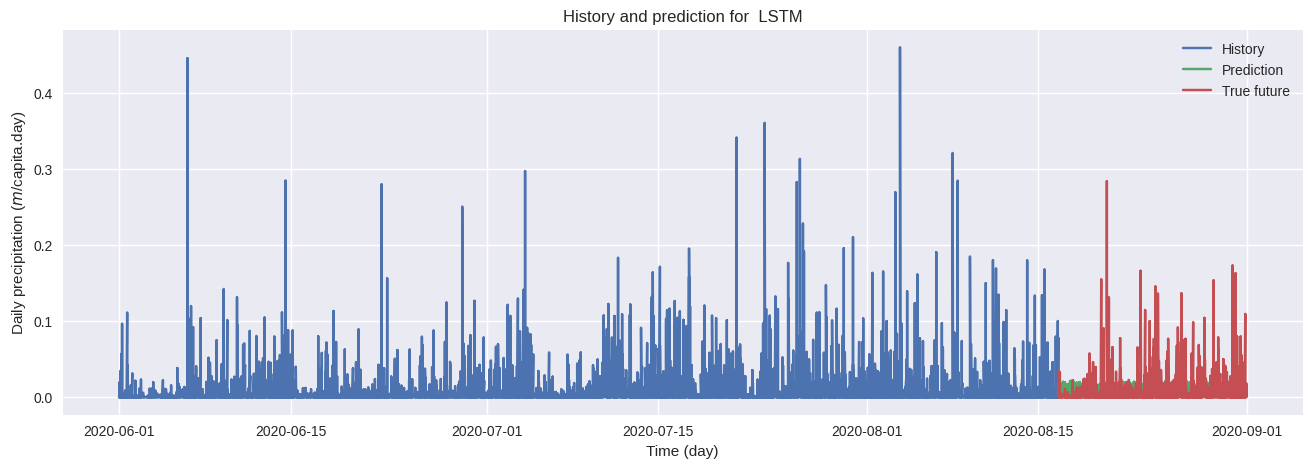

In [17]:
# Visualization
plt.style.use('seaborn')
#plt.style.use('fivethirtyeight')
#plt.style.use('seaborn-whitegrid')
#plt.style.use('ggplot')

# Plot histoy and future data
#colnames =data.loc[:,"Total_precip"].index
def plot_history_future(y_train, prediction, model_name):
    
    plt.figure(figsize=(16, 5))
    range_future = 100
    date_prediction=test_data.index[::range_future]
    range_history = 100
    date_history=train_data.index[::range_history]
    #date_test=date_test[:]
    #range_future = list(range(range_history, range_history + len(prediction)))

    plt.plot(date_history, np.array(y_train[::range_history]), label='History')
    plt.plot(date_prediction, np.array(y_pred[::range_future]),label='Prediction')
    plt.plot(date_prediction, np.array(y_test[::range_future]),label='True future')
    plt.title('History and prediction for ' + model_name)
    plt.legend(loc='upper right')
    plt.xlabel('Time (day)')
    plt.ylabel('Daily precipitation ($m$/capita.day)')
    #plt.savefig('C:/Users/nious/Documents/Medium/LSTM&GRU/3.jpg', format='jpg', dpi=1000)
plot_history_future(y_train, y_pred, ' LSTM')

In [19]:
# Define a function to calculate MAE and RMSE
def evaluate_prediction(predictions, actual, model_name):
    errors = predictions - actual
    mse = np.square(errors).mean()
    rmse = np.sqrt(mse)
    mae = np.abs(errors).mean()

    print(model_name + ':')
    print('Mean Squared  Error: {:.15f}'.format(mse))
    print('Mean Absolute Error: {:.10f}'.format(mae))
    print('Root Mean Square Error: {:.10f}'.format(rmse))
    #print('')

evaluate_prediction(y_pred, y_test, 'LSTM')

MemoryError: Unable to allocate 355. GiB for an array with shape (218187, 218187) and data type float64

In [ ]:
LSTM:
Mean Squared  Error: 0.000531694518761
Mean Absolute Error: 0.0071317794
Root Mean Square Error: 0.0230585021

In [21]:
Prediction =scaler_target.inverse_transform(y_pred)
Prediction=pd.DataFrame(Prediction ,columns =['Prediction'], index=test_data.index)

In [22]:
y_test = y_test.reshape(-1, 1)
Test =scaler_target.inverse_transform(y_test)
Test=pd.DataFrame(Test,columns =['Test'], index=test_data.index)

In [23]:
target_data=pd.concat([Test,Prediction], axis=1)
target_data

,Test,Prediction
time,,
2020-08-16 15:00:00,0.000052,0.000898
2020-08-16 15:00:00,0.000000,0.000572
2020-08-16 15:00:00,0.000000,0.000532
2020-08-16 15:00:00,0.000000,0.000371
2020-08-16 15:00:00,0.000000,0.000547
...,...,...
2020-08-31 23:00:00,0.000084,0.000424
2020-08-31 23:00:00,0.000054,0.000520
2020-08-31 23:00:00,0.000290,0.000584


/tmp/ipykernel_4718/1131482188.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


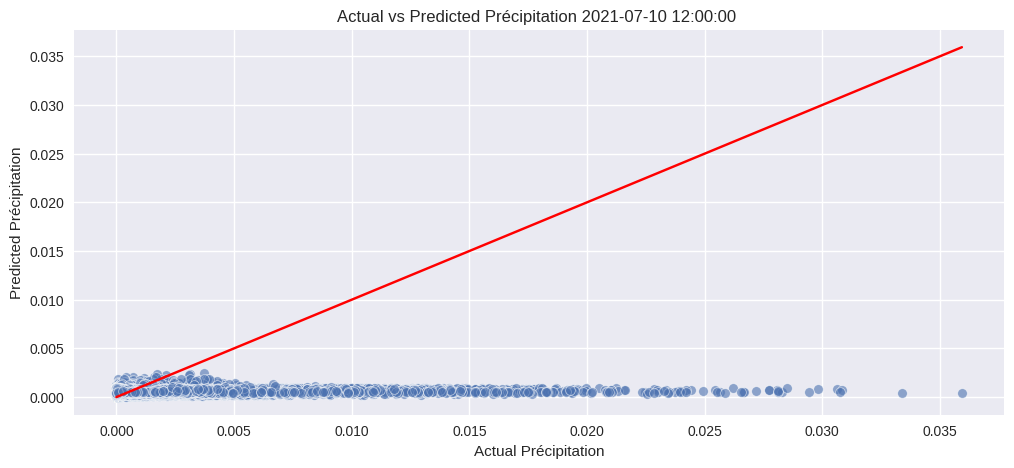

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn')

# Visualizing the regression results
plt.figure(figsize=(12,5))
sns.scatterplot(data=target_data, x=target_data['Test'], y=target_data['Prediction'], alpha=0.6)
sns.lineplot(x=[target_data['Test'].min(), 
                target_data['Test'].max()], y=[target_data['Test'].min(), target_data['Test'].max()], color='red')
plt.title('Actual vs Predicted Précipitation 2021-07-10 12:00:00 ')
plt.xlabel('Actual Précipitation')
plt.ylabel('Predicted Précipitation')
plt.show()

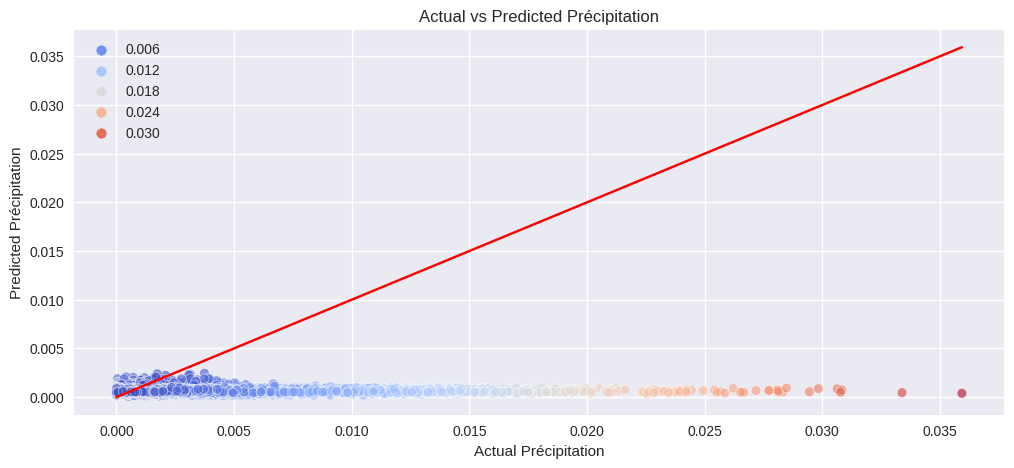

In [33]:
# Calculating the residuals (errors)
residuals = abs(target_data['Test'] - target_data['Prediction'])

# Creating an enhanced scatter plot with residuals
plt.figure(figsize=(12,5))
scatter = sns.scatterplot(x=target_data['Test'], y=target_data['Prediction'], hue=residuals, palette='coolwarm', alpha=0.6)
sns.lineplot(x=[target_data['Test'].min(), target_data['Test'].max()], 
             y=[target_data['Test'].min(), target_data['Test'].max()], color='red')

plt.title('Actual vs Predicted Précipitation')
plt.xlabel('Actual Précipitation')
plt.ylabel('Predicted Précipitation')
plt.show()

In [28]:
target_data['Prediction'].min()

-1.7237975043826737e-05

## Rolling Window Cross-Validation

In [80]:
for date in pd.date_range('2020-06-01 ', '2020-08-31 ', freq='MS'):
    #delta = date - pd.offsets.MonthBegin(1)
    train = dataset.loc[:date-pd.offsets.Day(1)]
    valid = dataset.loc[date:date+pd.offsets.MonthEnd(1)]

In [82]:
train

,longitude,latitude,Temp_2m,SST,level,Rel_hum,Spec_hum,U_wind,V_wind,Total_precip,longitude_lag1,latitude_lag1,Temp_2m_lag1,SST_lag1,level_lag1,Rel_hum_lag1,Spec_hum_lag1,U_wind_lag1,V_wind_lag1
time,,,,,,,,,,,,,,,,,,,
2020-06-01,0.416667,0.333333,0.311680,0.000000,0.805556,0.340712,0.441272,0.508732,0.589963,0.000000,0.358333,0.437500,0.252688,0.000000,0.805556,0.104797,0.168189,0.556770,0.505251
2020-06-01,1.000000,1.000000,0.427474,0.000000,0.000000,0.329610,0.000050,0.761022,0.724169,0.000000,0.416667,0.333333,0.311680,0.000000,0.805556,0.340712,0.441272,0.508732,0.589963
2020-06-01,0.750000,0.375000,0.326896,0.000000,0.000000,0.418847,0.000067,0.755634,0.685199,0.000000,1.000000,1.000000,0.427474,0.000000,0.000000,0.329610,0.000050,0.761022,0.724169
2020-06-01,0.941667,0.625000,0.501156,0.000000,1.000000,0.529983,0.833608,0.613765,0.618474,0.000000,0.750000,0.375000,0.326896,0.000000,0.000000,0.418847,0.000067,0.755634,0.685199
2020-06-01,0.233333,0.687500,0.423586,0.000000,0.111111,0.531627,0.003510,0.491964,0.660441,0.000016,0.941667,0.625000,0.501156,0.000000,1.000000,0.529983,0.833608,0.613765,0.618474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-07-31,0.500000,0.145833,0.282473,0.000000,1.000000,0.550627,0.871494,0.650018,0.579309,0.000000,0.750000,0.166667,0.285204,0.000000,0.805556,0.522237,0.581584,0.619354,0.590373
2020-07-31,0.825000,0.125000,0.293188,0.000000,0.666667,0.422864,0.351459,0.604539,0.568570,0.000621,0.500000,0.145833,0.282473,0.000000,1.000000,0.550627,0.871494,0.650018,0.579309
2020-07-31,0.733333,0.083333,0.317546,0.974478,0.000000,0.356509,0.000067,0.620409,0.487308,0.000481,0.825000,0.125000,0.293188,0.000000,0.666667,0.422864,0.351459,0.604539,0.568570


In [83]:
# Prepare data for LSTM
X_train = train[all_features].values
y_train = train[target_variable].values
X_test = valid[all_features].values
y_test = valid[target_variable].values

In [84]:
# Reshape data for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# LSTM testing 

In [85]:
# Create LSTM or GRU model
def create_model(units, m):
    model = Sequential()
    # First layer of LSTM
    model.add(m (units = units,activation="tanh", return_sequences = True, 
                 input_shape = [X_train.shape[1], X_train.shape[2]]))
    model.add(Dropout(0.4)) 
    # Second layer of LSTM
    model.add(m (units = units,return_sequences=False))                 
    model.add(Dropout(0.4))
    model.add(Dense(units = 1)) 
    #Compile model
    model.compile(loss='mse', optimizer='adam')
    return model

model_lstm = create_model(54, LSTM)

/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [86]:
# Fit BiLSTM, LSTM and GRU
def fit_model(model):
    early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                               patience = 10)

    # shuffle = False because the order of the data matters
    history = model.fit(X_train, y_train, epochs = 88, validation_split = 0.2,
                    batch_size = 16, shuffle = False, callbacks = [early_stop])
    return history


history_lstm = fit_model(model_lstm)


Epoch 1/88
42723/42723 ━━━━━━━━━━━━━━━━━━━━ 145s 3ms/step - loss: 2.0007e-04 - val_loss: 4.5939e-04
Epoch 2/88
42723/42723 ━━━━━━━━━━━━━━━━━━━━ 142s 3ms/step - loss: 1.9250e-04 - val_loss: 4.5791e-04
Epoch 3/88
42723/42723 ━━━━━━━━━━━━━━━━━━━━ 135s 3ms/step - loss: 1.9142e-04 - val_loss: 4.5751e-04
Epoch 4/88
42723/42723 ━━━━━━━━━━━━━━━━━━━━ 133s 3ms/step - loss: 1.9048e-04 - val_loss: 4.5499e-04
Epoch 5/88
42723/42723 ━━━━━━━━━━━━━━━━━━━━ 169s 4ms/step - loss: 1.8918e-04 - val_loss: 4.5438e-04
Epoch 6/88
42723/42723 ━━━━━━━━━━━━━━━━━━━━ 144s 3ms/step - loss: 1.8863e-04 - val_loss: 4.5883e-04
Epoch 7/88
42723/42723 ━━━━━━━━━━━━━━━━━━━━ 143s 3ms/step - loss: 1.8811e-04 - val_loss: 4.5401e-04
Epoch 8/88
42723/42723 ━━━━━━━━━━━━━━━━━━━━ 140s 3ms/step - loss: 1.8741e-04 - val_loss: 4.5526e-04
Epoch 9/88
42723/42723 ━━━━━━━━━━━━━━━━━━━━ 143s 3ms/step - loss: 1.8769e-04 - val_loss: 4.6025e-04
Epoch 10/88
42723/42723 ━━━━━━━━━━━━━━━━━━━━ 144s 3ms/step - loss: 1.8721e-04 - val_loss: 4.5842e-04

In [87]:
# Make predictions on the test set
y_pred = model_lstm.predict(X_test)

13360/13360 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step


In [89]:
Prediction =scaler_target.inverse_transform(y_pred)
Prediction=pd.DataFrame(Prediction ,columns =['Prediction'], index=valid.index)

In [90]:
y_test = y_test.reshape(-1, 1)
Test =scaler_target.inverse_transform(y_test)
Test=pd.DataFrame(Test,columns =['Test'], index=valid.index)

In [91]:
target_data=pd.concat([Test,Prediction], axis=1)
target_data

,Test,Prediction
time,,
2020-08-01,1.494084e-04,0.000044
2020-08-01,1.320019e-04,0.000033
2020-08-01,0.000000e+00,0.000059
2020-08-01,7.245690e-07,0.000033
2020-08-01,7.253140e-06,0.000003
...,...,...
2020-08-31,3.626570e-06,0.000101
2020-08-31,4.358962e-04,-0.000044
2020-08-31,0.000000e+00,0.000111


In [92]:
from sklearn.metrics import mean_squared_error, r2_score
# Define a function to calculate MAE and RMSE
def evaluate_prediction(predictions, actual, model_name):
    errors = predictions - actual
    mse = np.square(errors).mean()
    rmse = np.sqrt(mse)
    mae = np.abs(errors).mean()
    # score R carré du modèle
    r2 = r2_score(actual,predictions)
    print(model_name + ':')
    print('Mean Squared  Error: {:.15f}'.format(mse))
    print('Mean Absolute Error: {:.10f}'.format(mae))
    print('Root Mean Square Error: {:.10f}'.format(rmse))
    print('le score R2 score est {}'.format(r2))
    #print('')

evaluate_prediction(y_pred,y_test, 'LSTM')

LSTM:
Mean Squared  Error: 0.000531827335558
Mean Absolute Error: 0.0065244390
Root Mean Square Error: 0.0230613819
le score R2 score est -0.006673871619749638


# Hystory plot

/tmp/ipykernel_4792/3260497245.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


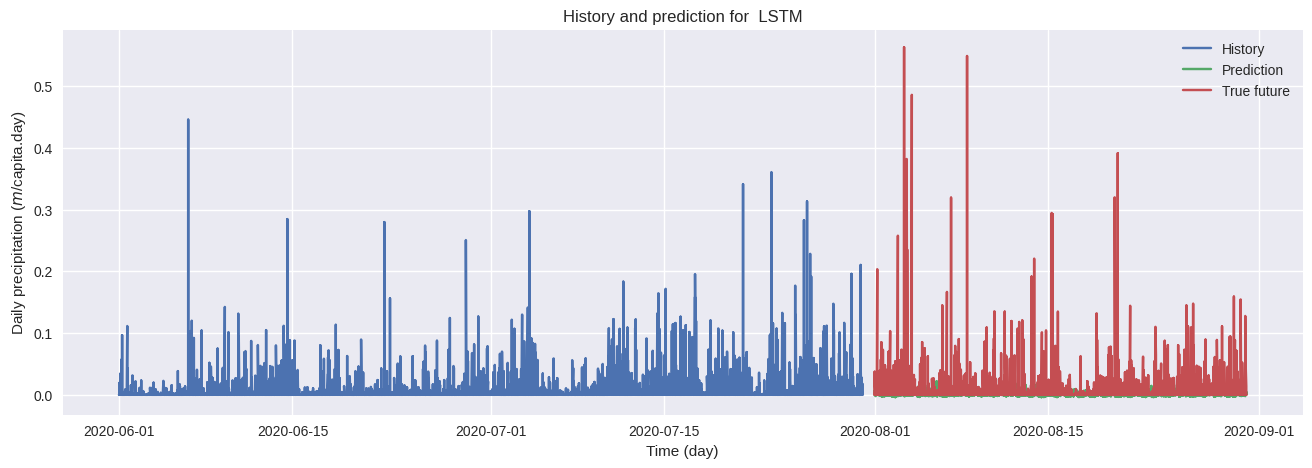

In [93]:
# Visualization
plt.style.use('seaborn')
#plt.style.use('fivethirtyeight')
#plt.style.use('seaborn-whitegrid')
#plt.style.use('ggplot')

# Plot histoy and future data
#colnames =data.loc[:,"Total_precip"].index
def plot_history_future(y_train, prediction, model_name):
    
    plt.figure(figsize=(16, 5))
    range_future = 100
    date_prediction=valid.index[::range_future]
    range_history = 100
    date_history=train.index[::range_history]
    #date_test=date_test[:]
    #range_future = list(range(range_history, range_history + len(prediction)))

    plt.plot(date_history, np.array(y_train[::range_history]), label='History')
    plt.plot(date_prediction, np.array(y_pred[::range_future]),label='Prediction')
    plt.plot(date_prediction, np.array(y_test[::range_future]),label='True future')
    plt.title('History and prediction for ' + model_name)
    plt.legend(loc='upper right')
    plt.xlabel('Time (day)')
    plt.ylabel('Daily precipitation ($m$/capita.day)')
    #plt.savefig('C:/Users/nious/Documents/Medium/LSTM&GRU/3.jpg', format='jpg', dpi=1000)
plot_history_future(y_train, y_pred, ' LSTM')

/tmp/ipykernel_4792/1131482188.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


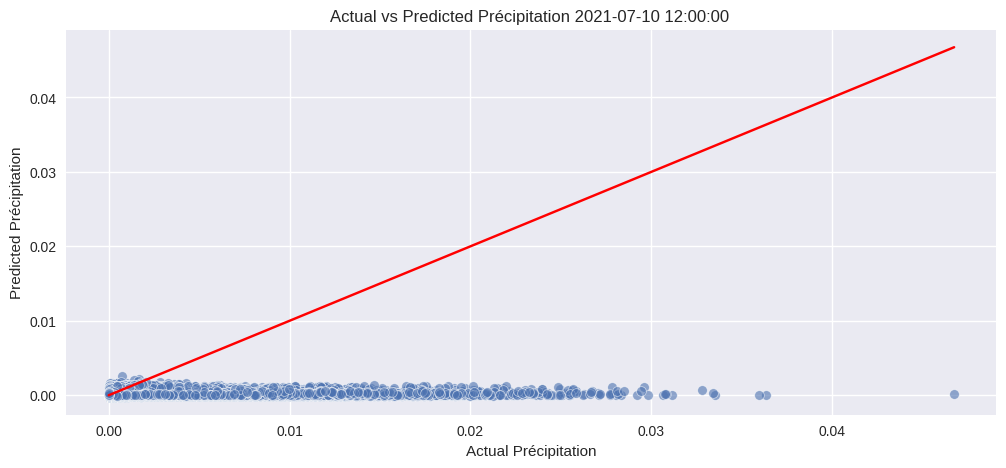

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn')

# Visualizing the regression results
plt.figure(figsize=(12,5))
sns.scatterplot(data=target_data, x=target_data['Test'], y=target_data['Prediction'], alpha=0.6)
sns.lineplot(x=[target_data['Test'].min(), 
                target_data['Test'].max()], y=[target_data['Test'].min(), target_data['Test'].max()], color='red')
plt.title('Actual vs Predicted Précipitation 2021-07-10 12:00:00 ')
plt.xlabel('Actual Précipitation')
plt.ylabel('Predicted Précipitation')
plt.show()

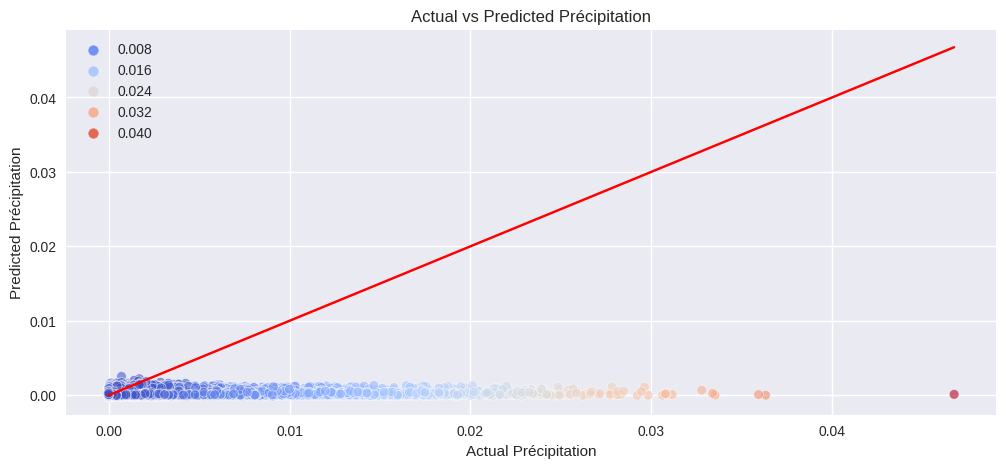

In [95]:
# Calculating the residuals (errors)
residuals = abs(target_data['Test'] - target_data['Prediction'])

# Creating an enhanced scatter plot with residuals
plt.figure(figsize=(12,5))
scatter = sns.scatterplot(x=target_data['Test'], y=target_data['Prediction'], hue=residuals, palette='coolwarm', alpha=0.6)
sns.lineplot(x=[target_data['Test'].min(), target_data['Test'].max()], 
             y=[target_data['Test'].min(), target_data['Test'].max()], color='red')

plt.title('Actual vs Predicted Précipitation')
plt.xlabel('Actual Précipitation')
plt.ylabel('Predicted Précipitation')
plt.show()

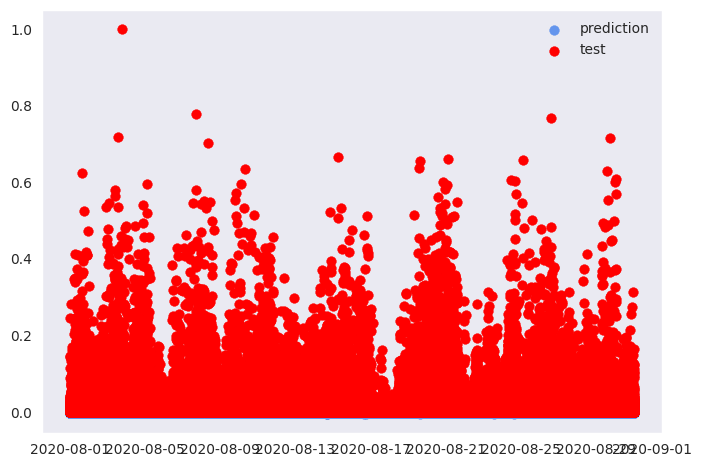

In [97]:
# plot the predicted values against the true values 
#plt.scatter(X, y, color='darkorange', label='data')
sns.set_style("dark")
plt.scatter(target_data.index, y_pred, color='cornflowerblue', label='prediction') 
plt.scatter(target_data.index, y_test, color='red', label='test') 
plt.legend() 
plt.show() 

/tmp/ipykernel_4792/2745804754.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


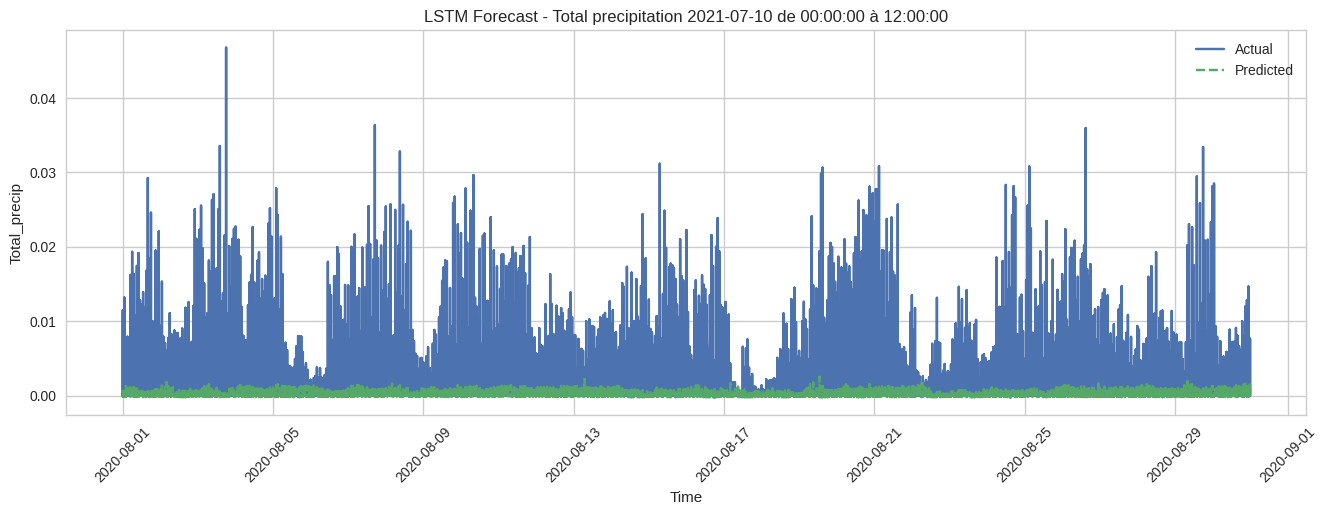

In [96]:
# Visualization
#plt.style.use('seaborn')
#plt.style.use('fivethirtyeight')
plt.style.use('seaborn-whitegrid')
#plt.style.use('ggplot')

#########################################################
range_future =10
index_test=target_data.index
plt.figure(figsize=(16, 5))
plt.plot(target_data.index, target_data.Test, label='Actual')
plt.plot(target_data.index, target_data.Prediction, label='Predicted', linestyle='--')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel(target_variable)
plt.title('LSTM Forecast - Total precipitation 2021-07-10 de 00:00:00 à 12:00:00')
plt.legend()
plt.savefig('Forecast_lstm.png')         
plt.show()
